# Probability density matrix 

 In this notebook we show how to call the probability densitity matrix for arbitrary NSI

First import the model class

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from snudd.models import GeneralNSI

We will start with the Standard Model (SM), i.e. all NSI parameters are set to zero.

In [2]:
SM_matrix = np.array([[0, 0, 0],
                      [0, 0, 0],
                      [0, 0, 0]])

eta = 0
phi = 0

sm_model = GeneralNSI(SM_matrix, eta, phi)

We import the probabilities module

In [3]:
import snudd.nsi.nsi_probabilities as probs

Declare neutrino energy array 

In [4]:
enus = np.geomspace(1e-6,1e0,200)

## Neutrino survival and dissapearance probabilities

For example, to call the $\nu_{e}$ survival probabilities 

In [5]:
probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B') # Survival

array([0.5493961 , 0.54939408, 0.54939191, 0.54938959, 0.5493871 ,
       0.54938443, 0.54938157, 0.5493785 , 0.54937521, 0.54937169,
       0.54936791, 0.54936387, 0.54935953, 0.54935488, 0.54934989,
       0.54934454, 0.54933881, 0.54933267, 0.54932609, 0.54931903,
       0.54931147, 0.54930336, 0.54929467, 0.54928535, 0.54927536,
       0.54926465, 0.54925318, 0.54924087, 0.54922768, 0.54921354,
       0.54919838, 0.54918213, 0.54916471, 0.54914604, 0.54912602,
       0.54910455, 0.54908154, 0.54905687, 0.54903043, 0.54900207,
       0.54897168, 0.54893908, 0.54890414, 0.54886667, 0.5488265 ,
       0.54878343, 0.54873725, 0.54868773, 0.54863462, 0.54857768,
       0.54851662, 0.54845114, 0.54838091, 0.5483056 , 0.54822483,
       0.54813819, 0.54804527, 0.5479456 , 0.54783868, 0.54772398,
       0.54760094, 0.54746892, 0.54732728, 0.54717529, 0.5470122 ,
       0.54683717, 0.54664931, 0.54644767, 0.54623122, 0.54599885,
       0.54574934, 0.54548142, 0.54519369, 0.54488464, 0.54455

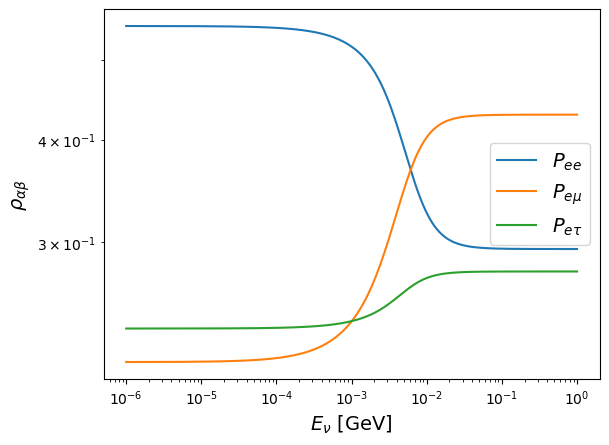

In [6]:
plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B'), label=r'$P_{ee}$')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_emu_3nu(enus, '8B'), label=r'$P_{e\mu}$')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_etau_3nu(enus, '8B'), label=r'$P_{e\tau}$' )



plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

plt.legend(fontsize=14)


## Neutrino density matrix $\rho$

Now we use the more general probability density matrix as in equation (1) of our [paper](https://inspirehep.net/literature/2636793)

$$\frac{\rm{d}R}{\rm{d}E_R}=  N_T \int_{E_\nu^\mathrm{min}} \frac{\rm{d}\phi_\nu}{\rm{d}E_\nu}\,  \mathrm{Tr}\left[ \rho\, \frac{\rm{d}\zeta}{ \rm{d}E_R}\right] \, \rm{d} E_\nu\, .$$

We can call this matrix in a similar way to before 

In [6]:
density_sm = probs.DensityMatrixCalculator(sm_model).density(enus, '8B')

The output is an array of $n\times3\times3$ matrix, where $n$ is the length of $E_\nu$  

In [7]:
np.shape(density_sm)

(200, 3, 3)

For comparison we can plot the diagonal denisty matrix elements against the survival and disappearance probabilities from before.

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

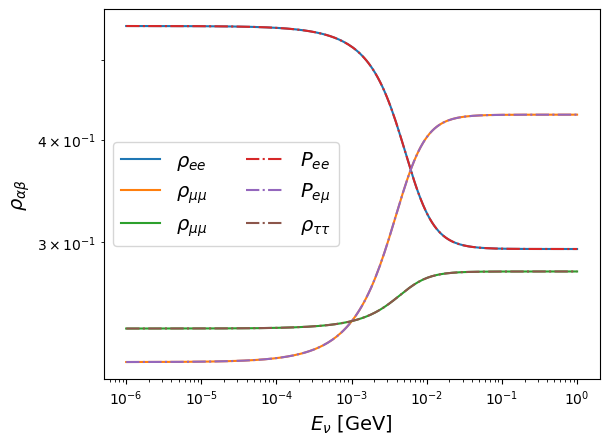

In [10]:
plt.loglog(enus,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(enus,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

plt.loglog(enus,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}$')


plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-.' )

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

For completness, let us plot all six independent density matrix elements.

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

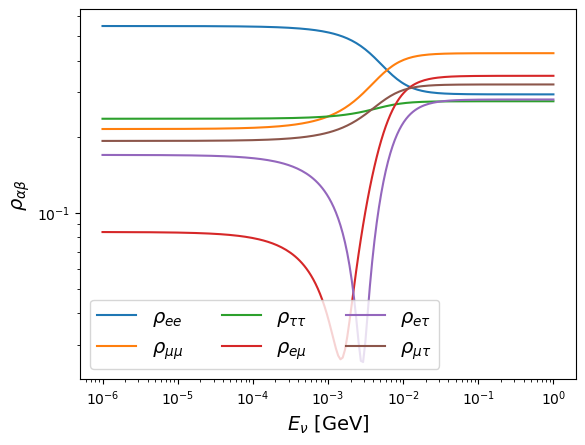

In [11]:
plt.loglog(enus, abs(density_sm[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(enus, abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}$')
plt.loglog(enus, abs(density_sm[:, 2,2]),  label=r'$\rho_{\tau\tau}$')
plt.loglog(enus, abs(density_sm[:, 0,1]),  label=r'$\rho_{e\mu}$')
plt.loglog(enus, abs(density_sm[:, 0,2]),  label=r'$\rho_{e\tau}$')
plt.loglog(enus, abs(density_sm[:, 1,2]),  label=r'$\rho_{\mu\tau}$')

plt.legend(fontsize=14, ncol=3)

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## Adding NSI

Now we can calculate the density matrix with nonzero NSI parameters. For example with $\varepsilon_{\mu\tau}=0.1$ with equal couplings to protons and neutrons ($\eta=\pi/4$).

In [8]:
eps_mt = 0.1*(1+1j)

NSI_matrix = np.array([[0.0, 0.0, 0.0],
                       [0.0, 0.0, eps_mt],
                       [0.0, eps_mt.conjugate, 0.0]])

eta = np.pi/4
phi = 0

NSI_model = GeneralNSI(NSI_matrix, eta, phi)

In [9]:
density_NSI = probs.DensityMatrixCalculator(NSI_model).density(enus, '8B')

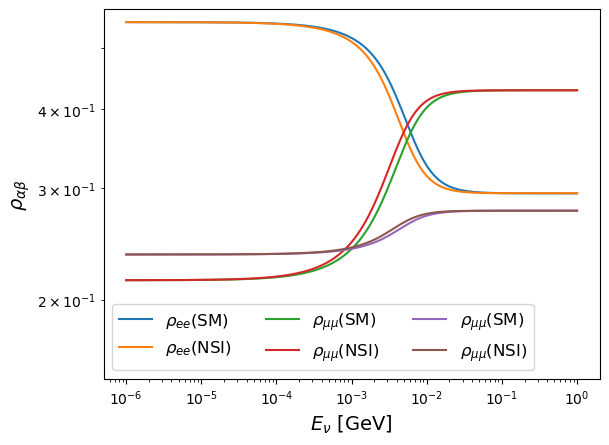

In [10]:
plt.plot(enus,abs(density_sm[:, 0,0]),  label=r'$\rho_{ee} ({\rm SM})$')
plt.loglog(enus,abs(density_NSI[:, 0,0]),  label=r'$\rho_{ee}({\rm NSI})$')

plt.loglog(enus,abs(density_sm[:, 1,1]),  label=r'$\rho_{\mu\mu}({\rm SM})$')
plt.loglog(enus,abs(density_NSI[:, 1,1]),  label=r'$\rho_{\mu\mu}({\rm NSI})$')


plt.loglog(enus,abs(density_sm[:, 2,2]),  label=r'$\rho_{\mu\mu}({\rm SM})$')



plt.loglog(enus,abs(density_NSI[:, 2,2]),  label=r'$\rho_{\mu\mu}({\rm NSI})$')


plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

plt.ylim(ymin=1.5e-1)
plt.legend(fontsize=12, ncol=3)

#### Altering the oscillation parameters 

In [15]:
from snudd.nsi.oscillation import OscillationParameters
from snudd.nsi.oscillation import osc_params_old

In [16]:
# UPDATED osc vals from 2410.05380 (IC24 w/ SK)
delta_m12 = 7.49e-5 * (1e-9) ** 2  # GeV^2
delta_m31 = 2.513e-3 *( 1e-9) ** 2
theta_12  = 33.68 * np.pi / 180
theta_13  = 8.56 * np.pi / 180  # NORMAL ORDERING
theta_23  = 43.3 * np.pi / 180
#delta_cp = np.pi  # CP angle

In [17]:
# Delta CP = pi
params_cp_pi = OscillationParameters(delta_m12,
                                     delta_m31,
                                     theta_12,
                                     theta_13,
                                     theta_23,
                                     np.pi)

In [18]:
# Delta CP = pi/2 
params_cp_pi_2 = OscillationParameters(delta_m12,
                                       delta_m31,
                                       theta_12,
                                       theta_13,
                                       theta_23,
                                       np.pi/2)

In [19]:
probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi).prob_ee_3nu(enus, '8B') # Survival

array([0.5493961 , 0.54939408, 0.54939191, 0.54938959, 0.5493871 ,
       0.54938443, 0.54938157, 0.5493785 , 0.54937521, 0.54937169,
       0.54936791, 0.54936387, 0.54935953, 0.54935488, 0.54934989,
       0.54934454, 0.54933881, 0.54933267, 0.54932609, 0.54931903,
       0.54931147, 0.54930336, 0.54929467, 0.54928535, 0.54927536,
       0.54926465, 0.54925318, 0.54924087, 0.54922768, 0.54921354,
       0.54919838, 0.54918213, 0.54916471, 0.54914604, 0.54912602,
       0.54910455, 0.54908154, 0.54905687, 0.54903043, 0.54900207,
       0.54897168, 0.54893908, 0.54890414, 0.54886667, 0.5488265 ,
       0.54878343, 0.54873725, 0.54868773, 0.54863462, 0.54857768,
       0.54851662, 0.54845114, 0.54838091, 0.5483056 , 0.54822483,
       0.54813819, 0.54804527, 0.5479456 , 0.54783868, 0.54772398,
       0.54760094, 0.54746892, 0.54732728, 0.54717529, 0.5470122 ,
       0.54683717, 0.54664931, 0.54644767, 0.54623122, 0.54599885,
       0.54574934, 0.54548142, 0.54519369, 0.54488464, 0.54455

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

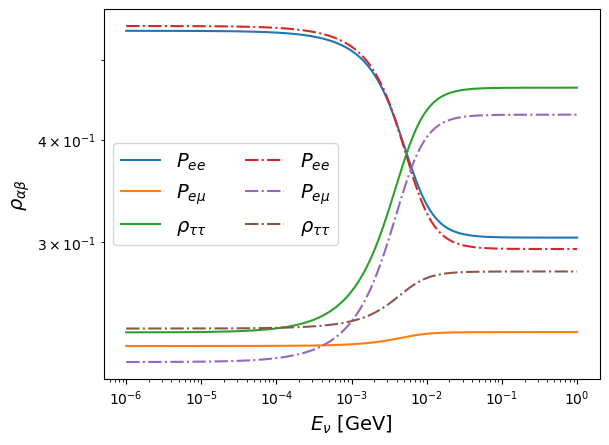

In [20]:
# Compare to old oscillation parameters


plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=osc_params_old).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=osc_params_old).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=osc_params_old).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-' )

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-.' )

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

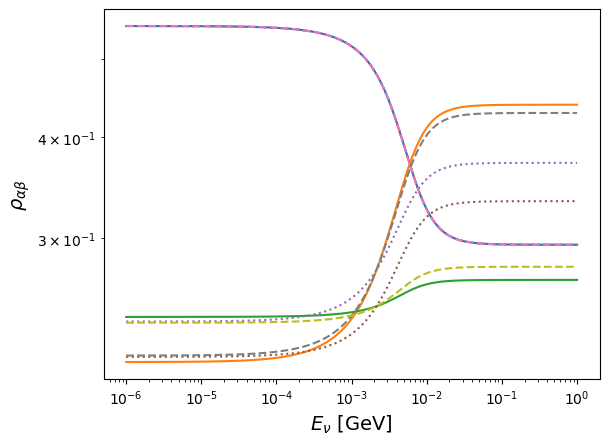

In [21]:

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-' )

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi_2).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls=':')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi_2).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls=':')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi_2).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls=':' )

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='--')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='--')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='--' )

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
#plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

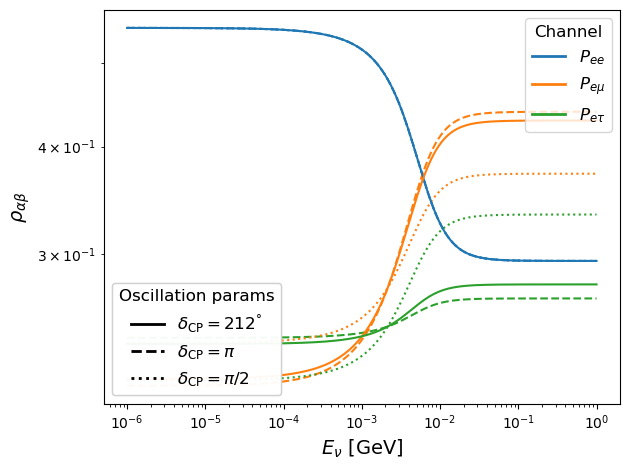

In [22]:
from matplotlib.lines import Line2D

# --- choose three consistent colors from the current matplotlib cycle ---
cycle_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {
    'ee':   cycle_colors[0],
    'emu':  cycle_colors[1],
    'etau': cycle_colors[2],
}

# --- define linestyles and labels for the three osc. parameter sets ---
# Adjust these δ_CP labels to match your actual params if needed.
ls_label_map = {
    'best': {'ls': '-', 'label': r'$\delta_{\rm CP}=212^\degree$'},
    'pi':   {'ls': '--',  'label': r'$\delta_{\rm CP}=\pi$'},
    'pi2':  {'ls': ':',  'label': r'$\delta_{\rm CP}=\pi/2$'},
}

# Build calculators once (avoids repeated instantiation)
calc_pi   = probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi)
calc_pi2  = probs.ProbabilityCalculator(sm_model, osc_params=params_cp_pi_2)
calc_best = probs.ProbabilityCalculator(sm_model)  # default osc params

# --- plot: each channel has a fixed color; each param-set uses a different linestyle ---
# δ_CP = π
plt.loglog(enus, calc_pi.prob_ee_3nu(enus, '8B'),   ls=ls_label_map['pi']['ls'],   color=color_map['ee'])
plt.loglog(enus, calc_pi.prob_emu_3nu(enus, '8B'),  ls=ls_label_map['pi']['ls'],   color=color_map['emu'])
plt.loglog(enus, calc_pi.prob_etau_3nu(enus, '8B'), ls=ls_label_map['pi']['ls'],   color=color_map['etau'])

# δ_CP = π/2
plt.loglog(enus, calc_pi2.prob_ee_3nu(enus, '8B'),   ls=ls_label_map['pi2']['ls'],  color=color_map['ee'])
plt.loglog(enus, calc_pi2.prob_emu_3nu(enus, '8B'),  ls=ls_label_map['pi2']['ls'],  color=color_map['emu'])
plt.loglog(enus, calc_pi2.prob_etau_3nu(enus, '8B'), ls=ls_label_map['pi2']['ls'],  color=color_map['etau'])

# δ_CP = 0
plt.loglog(enus, calc_best.prob_ee_3nu(enus, '8B'),   ls=ls_label_map['best']['ls'], color=color_map['ee'])
plt.loglog(enus, calc_best.prob_emu_3nu(enus, '8B'),  ls=ls_label_map['best']['ls'], color=color_map['emu'])
plt.loglog(enus, calc_best.prob_etau_3nu(enus, '8B'), ls=ls_label_map['best']['ls'], color=color_map['etau'])

# --- labels & axes ---
plt.xlabel(r'$E_{\nu}\,\,[\mathrm{GeV}]$', fontsize=14)
plt.ylabel(r'$\rho_{\alpha\beta}$', fontsize=14)

# --- bespoke legends ---
# 1) Color legend: one entry per channel (shows colors only)
color_handles = [
    Line2D([0],[0], lw=2, color=color_map['ee'],   ls='-', label=r'$P_{ee}$'),
    Line2D([0],[0], lw=2, color=color_map['emu'],  ls='-', label=r'$P_{e\mu}$'),
    Line2D([0],[0], lw=2, color=color_map['etau'], ls='-', label=r'$P_{e\tau}$'),
]
leg1 = plt.legend(handles=color_handles, title="Channel", fontsize=12, title_fontsize=12, loc='upper right')

# 2) Linestyle legend: one entry per δ_CP (shows linestyles only)
ls_handles = [
    Line2D([0],[0], lw=2, color='black', ls=ls_label_map['best']['ls'], label=ls_label_map['best']['label']),
    Line2D([0],[0], lw=2, color='black', ls=ls_label_map['pi']['ls'],   label=ls_label_map['pi']['label']),
    Line2D([0],[0], lw=2, color='black', ls=ls_label_map['pi2']['ls'],  label=ls_label_map['pi2']['label']),
]
leg2 = plt.legend(handles=ls_handles, title=r'Oscillation params', fontsize=12, title_fontsize=12, loc='lower left')

# Make both legends show
ax = plt.gca()
ax.add_artist(leg1)
ax.add_artist(leg2)

plt.tight_layout()
# plt.savefig('solar_probs.pdf', bbox_inches='tight')
plt.show()


In [23]:
density_sm_cppi = probs.DensityMatrixCalculator(sm_model, osc_params=params_cp_pi).density(enus, '8B')

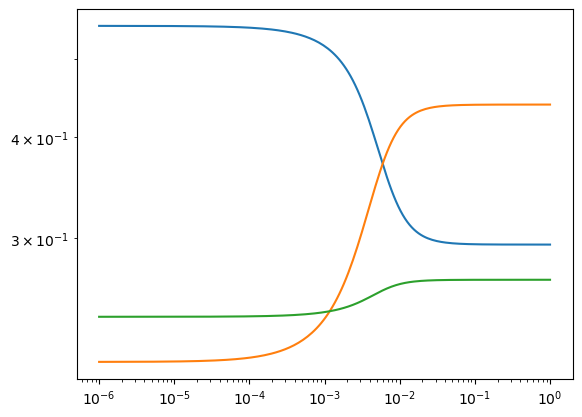

In [24]:
plt.loglog(enus,abs(density_sm_cppi[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(enus,abs(density_sm_cppi[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

plt.loglog(enus,abs(density_sm_cppi[:, 2,2]),  label=r'$\rho_{\mu\mu}$')

Text(0.5, 1.0, '$\\delta_{\\rm cp}=\\pi$')

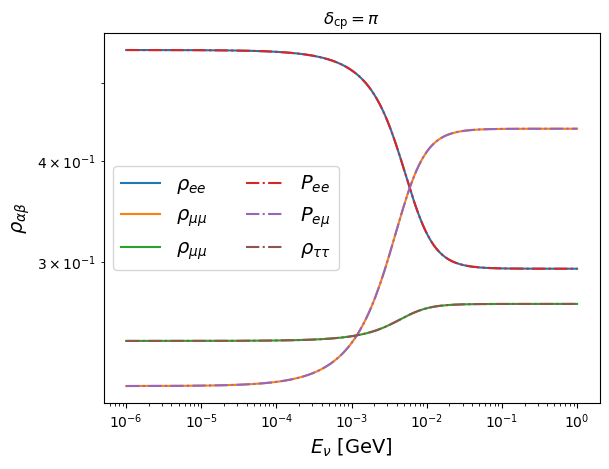

In [25]:
plt.loglog(enus,abs(density_sm_cppi[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(enus,abs(density_sm_cppi[:, 1,1]),  label=r'$\rho_{\mu\mu}$')

plt.loglog(enus,abs(density_sm_cppi[:, 2,2]),  label=r'$\rho_{\mu\mu}$')


plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model,osc_params=params_cp_pi).prob_ee_3nu(enus, '8B'),
           label=r'$P_{ee}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model,osc_params=params_cp_pi).prob_emu_3nu(enus, '8B'),
           label=r'$P_{e\mu}$', ls='-.')

plt.loglog(enus, 
           probs.ProbabilityCalculator(sm_model,osc_params=params_cp_pi).prob_etau_3nu(enus, '8B'),
           label=r'$\rho_{\tau\tau}$', ls='-.' )

plt.ylabel(r'$\rho_{\alpha\beta}$', size=14)
plt.legend(fontsize=14, ncol=2)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

plt.title(r"$\delta_{\rm cp}=\pi$")